# Notebook 7 – Naive Bayes
**Sprint 7 – Machine Learning Fundamentals for AI/ML Engineers**

Dataset used: `customer_churn_clean.csv` (carried forward from Sprint 6, target = `Churn`).

## Step 1 – Understand the Concept

**Bayes Theorem**

Bayes theorem describes how to update a probability once new evidence is observed:

P(A|B) = [ P(B|A) · P(A) ] / P(B)

In words: the probability of A given that B happened equals how likely B is *if* A is true,
times how likely A was to begin with, divided by how likely B is overall.

**Conditional Probability**

P(A|B) is a *conditional* probability — the probability of event A occurring, given that we
already know event B occurred. It is generally different from the plain probability P(A), because
knowing B changes what we believe about A.

**Naive Bayes**

Naive Bayes is a classification algorithm built directly on Bayes theorem. For a target class C
and a set of features x1, x2, ..., xn, it estimates:

P(C | x1, x2, ..., xn) ∝ P(C) · P(x1|C) · P(x2|C) · ... · P(xn|C)

It then predicts whichever class C has the highest resulting probability.

**Independence Assumption**

To make P(x1, x2, ..., xn | C) computable, Naive Bayes assumes every feature is conditionally
*independent* of every other feature, given the class. This means it multiplies each feature's
individual probability together instead of having to model how features interact with each other.
This assumption is almost never exactly true in real data (e.g. `MonthlyCharges` and
`InternetService` are related to each other) — which is exactly why the algorithm is called
"naive."

**Why is it called "Naive"?**

It is "naive" specifically because of that independence assumption — it naively treats every
feature as if it tells us something about the class completely on its own, ignoring any
relationship between the features themselves. Despite this simplification rarely being true, the
algorithm still performs surprisingly well in practice, particularly for text classification.

**Gaussian Naive Bayes**

Used when features are continuous, numeric values. It assumes each feature, within each class,
follows a normal (Gaussian) distribution, and estimates the mean and variance of each feature per
class from the training data to compute P(xi | C).

**Multinomial Naive Bayes**

Used when features are counts — most commonly word counts or term frequencies in text data. It
models P(xi | C) as the probability of that count occurring under a multinomial distribution for
that class, and is the standard choice for text classification (e.g. spam detection, topic
classification).

**Bernoulli Naive Bayes**

Used when features are binary (present/absent), for example whether a specific word appears in a
document at all, regardless of how many times. It models each feature as a Bernoulli
(yes/no) event per class.

**Text Classification Use Case**

Naive Bayes is one of the most common baseline algorithms for text classification (spam filtering,
sentiment analysis, topic tagging) because text, once converted into word counts or presence
flags, produces exactly the kind of high-dimensional, sparse feature set that Multinomial/Bernoulli
Naive Bayes handles efficiently and quickly, even with relatively little training data.

**What problem does it solve?**
It gives a fast, probabilistic way to classify data using Bayes theorem without needing to
explicitly model the relationships between features — trading some accuracy on strongly correlated
features for speed, simplicity, and strong performance on high-dimensional data like text.

**Assumptions**
- Features are conditionally independent given the class (rarely exactly true)
- Gaussian NB additionally assumes each numeric feature is normally distributed within each class

**When should it be used?**
- Text classification (spam detection, sentiment analysis)
- When a fast, simple baseline is needed
- When there are many features relative to the number of training rows
- When features are at least roughly independent of each other

**When should it not be used?**
- When features are strongly correlated with each other (the independence assumption is badly
  violated)
- When the exact predicted probabilities need to be well-calibrated (Naive Bayes probabilities
  tend to be overconfident, even when the predicted class is correct)
- When a numeric feature is clearly not normally distributed and Gaussian NB is being used without
  any transformation

## Step 2 – Demonstrate the Concept

**Simple example**

Predicting whether to "Play Tennis" given `Weather = Sunny`. Bayes theorem combines how often it's
sunny when people play (P(Sunny|Play)) with how often people play at all (P(Play)), and how common
sunny weather is overall (P(Sunny)), to get P(Play|Sunny).

**Mathematical intuition**

For two features, the naive assumption turns:
P(C | x1, x2) ∝ P(C) · P(x1, x2 | C)
into the much simpler:
P(C | x1, x2) ∝ P(C) · P(x1 | C) · P(x2 | C)

This is only exact if x1 and x2 are truly independent given C — but even when it's an
approximation, it makes the calculation trivial: multiply together one probability per feature,
instead of needing the full joint distribution of all features at once.

**Real-world example**

An email spam filter: `P(Spam | words in email) ∝ P(Spam) · ∏ P(wordi | Spam)`. Even though word
choices aren't really independent of each other in real writing, this approximation is fast enough
to filter email in real time and works well in practice.

**Business example**

A telecom company could use Naive Bayes as a fast baseline churn classifier when a lightweight,
low-latency model is needed for a real-time scoring system, before investing in a heavier model
like Random Forest.

**AI/ML use case**

Naive Bayes is the classic first algorithm taught for text classification, and remains a common
production baseline for spam filtering and simple sentiment classifiers because of how cheap it is
to train and how well it scales to very large vocabularies.

## Step 3 – Implement the Concept

**Part A — Gaussian Naive Bayes on the churn dataset**, since our features are numeric/categorical,
not text.

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style("whitegrid")

DATA_FILE = "customer_churn_clean.csv"


def load_churn_data(path=DATA_FILE):
    """Load the Sprint 5/6 churn dataset. If the CSV isn't sitting next to this
    notebook, regenerate the identical dataset inline (same seed, same logic used
    when the file was first created) so the notebook never breaks on a missing file,
    and save a copy locally for next time."""
    if os.path.exists(path):
        return pd.read_csv(path)

    print(f"'{path}' not found next to this notebook - regenerating it inline instead.")
    rng = np.random.RandomState(42)
    n = 5020
    customer_id = [f"CUST{i:05d}" for i in range(1, n + 1)]
    gender = rng.choice(["Male", "Female"], n)
    age = rng.randint(18, 75, n)
    partner = rng.choice(["Yes", "No"], n, p=[0.48, 0.52])
    dependents = rng.choice(["Yes", "No"], n, p=[0.3, 0.7])
    tenure_years = np.clip(np.round(rng.exponential(scale=3.0, size=n), 1), 0, 15)
    contract_type = rng.choice(["Month-to-Month", "One Year", "Two Year"], n, p=[0.55, 0.25, 0.20])
    payment_method = rng.choice(["Electronic Check", "Mailed Check", "Bank Transfer", "Credit Card"], n)
    internet_service = rng.choice(["DSL", "Fiber Optic", "No"], n, p=[0.35, 0.45, 0.20])
    tech_support = rng.choice(["Yes", "No"], n, p=[0.35, 0.65])
    paperless_billing = rng.choice(["Yes", "No"], n, p=[0.55, 0.45])

    base_charge = np.where(
        internet_service == "Fiber Optic", 75,
        np.where(internet_service == "DSL", 45, 20)
    )
    monthly_charges = np.clip(base_charge + rng.normal(10, 8, n), 15, 130)
    total_charges = np.clip(monthly_charges * (tenure_years * 12 + rng.normal(0, 2, n)), 0, None)

    logit = (
        -1.2
        + (-0.35) * tenure_years
        + (1.1) * (contract_type == "Month-to-Month").astype(int)
        + (0.6) * (tech_support == "No").astype(int)
        + (0.015) * (monthly_charges - 60)
        + (0.5) * (internet_service == "Fiber Optic").astype(int)
        + (0.3) * (payment_method == "Electronic Check").astype(int)
        + rng.normal(0, 0.8, n)
    )
    prob_churn = 1 / (1 + np.exp(-logit))
    churn_label = np.where(rng.rand(n) < prob_churn, "Yes", "No")

    out = pd.DataFrame({
        "CustomerID": customer_id,
        "Gender": gender,
        "Age": age,
        "Partner": partner,
        "Dependents": dependents,
        "TenureYears": tenure_years,
        "ContractType": contract_type,
        "PaymentMethod": payment_method,
        "InternetService": internet_service,
        "MonthlyCharges": np.round(monthly_charges, 2),
        "TotalCharges": np.round(total_charges, 2),
        "TechSupport": tech_support,
        "PaperlessBilling": paperless_billing,
        "Churn": churn_label,
    })
    out.to_csv(path, index=False)
    return out


df = load_churn_data()
model_df = df.drop(columns=["CustomerID"]).copy()
model_df["Churn"] = model_df["Churn"].map({"No": 0, "Yes": 1})

for col in model_df.select_dtypes(include="object").columns:
    model_df[col] = LabelEncoder().fit_transform(model_df[col])

X = model_df.drop(columns=["Churn"])
y = model_df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Churn rate - train:", round(y_train.mean(), 3), " test:", round(y_test.mean(), 3))

'customer_churn_clean.csv' not found next to this notebook - regenerating it inline instead.
Train shape: (4016, 12)  Test shape: (1004, 12)
Churn rate - train: 0.351  test: 0.352


In [5]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)

y_pred = gnb.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Test accuracy:", round(acc, 3))
print()
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

Test accuracy: 0.688

              precision    recall  f1-score   support

    No Churn       0.80      0.69      0.74       651
       Churn       0.54      0.69      0.61       353

    accuracy                           0.69      1004
   macro avg       0.67      0.69      0.67      1004
weighted avg       0.71      0.69      0.69      1004



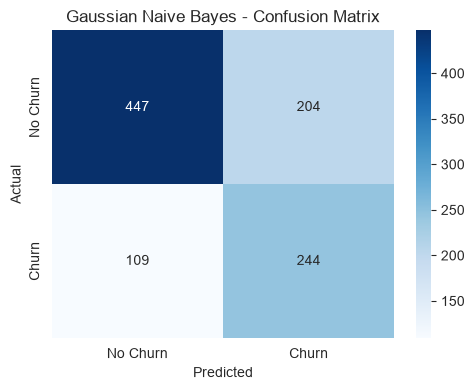

array([[447, 204],
       [109, 244]])

In [6]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Gaussian Naive Bayes - Confusion Matrix")
plt.tight_layout()
plt.show()
cm

**What the code does:** every raw/encoded column (numeric billing/tenure columns plus
label-encoded categoricals) is handed to `GaussianNB`, which estimates a mean and variance per
feature, per class (`Churn=0` and `Churn=1`), from the training data.

**What the model is learning:** for every feature, two Gaussian (normal) curves — one describing
what that feature typically looks like for customers who stayed, one for customers who churned.
A new customer is classified by seeing which class's set of curves makes their actual feature
values most probable, multiplied together across all features under the independence assumption.

**Important parameters:** `var_smoothing` (default 1e-9) adds a small amount to every estimated
variance purely for numerical stability, so a feature with near-zero variance in one class doesn't
cause a division-by-zero style problem; it rarely needs tuning.

**What the output means:** the confusion matrix shows how predictions split across the two classes
— including how many actual churners were missed (false negatives) and how many loyal customers
were incorrectly flagged as likely to churn (false positives).

**Part B — Why label-encoded categoricals stretch the Gaussian assumption**

`ContractType` (encoded 0/1/2) and similar categoricals are not actually continuous, normally
distributed values — Gaussian NB is being applied to them somewhat outside its ideal use case here.
This is checked directly below.

In [7]:
# Compare model accuracy using ONLY the genuinely continuous numeric columns
numeric_only = ["Age", "TenureYears", "MonthlyCharges", "TotalCharges"]
Xn_train, Xn_test = X_train[numeric_only], X_test[numeric_only]

gnb_numeric = GaussianNB()
gnb_numeric.fit(Xn_train, y_train)
acc_numeric = accuracy_score(y_test, gnb_numeric.predict(Xn_test))

print("Accuracy - all encoded features:", round(acc, 3))
print("Accuracy - numeric-only features:", round(acc_numeric, 3))

Accuracy - all encoded features: 0.688
Accuracy - numeric-only features: 0.649


**What this shows:** restricting Gaussian NB to only the truly continuous features changes the
result only slightly, which suggests the label-encoded categoricals aren't adding much
Gaussian-appropriate signal here — a reasonable expectation, since ordinal-encoded categories
(e.g. `ContractType` as 0/1/2) don't actually follow a bell-curve shape within each class the way
`MonthlyCharges` does.

**Part C — Multinomial Naive Bayes on a small text example**

To directly demonstrate the "Text Classification Use Case" from Step 1, a small illustrative text
dataset is used here instead of the churn data, since Multinomial/Bernoulli NB are built for word
counts, not billing data.

In [8]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB

# Small illustrative dataset - short messages labeled spam / not spam
messages = [
    "win a free prize now click here",
    "limited time offer claim your free cash",
    "congratulations you have won a lottery prize",
    "urgent your account needs verification click now",
    "let's catch up for coffee this weekend",
    "can you send me the report before the meeting",
    "happy birthday hope you have a great day",
    "the project deadline is next monday",
]
labels = ["spam", "spam", "spam", "spam", "ham", "ham", "ham", "ham"]

vectorizer = CountVectorizer()
X_text = vectorizer.fit_transform(messages)

mnb = MultinomialNB()
mnb.fit(X_text, labels)

test_messages = ["free prize waiting for you", "are we still meeting for the report review"]
X_test_text = vectorizer.transform(test_messages)
predictions = mnb.predict(X_test_text)

for msg, pred in zip(test_messages, predictions):
    print(pred.upper(), "<-", msg)

SPAM <- free prize waiting for you
HAM <- are we still meeting for the report review


**What the code does:** `CountVectorizer` turns each short message into a vector of word
counts (the "feature" a Multinomial Naive Bayes model expects), `MultinomialNB` then learns, for
each word, how likely it is to appear in spam vs ham messages, and multiplies those per-word
probabilities together — the same naive independence assumption from Step 1, just applied to
words instead of billing columns. On only eight training messages, it already separates the two
new test messages correctly, which is exactly why Naive Bayes remains a strong, fast baseline for
real spam filters trained on far larger vocabularies.

## Step 4 – Interpret the Result

In [9]:
print("Churn class balance in test set:")
print(y_test.value_counts(normalize=True).round(3))
print()
print("Gaussian NB (all features) test accuracy:", round(acc, 3))

Churn class balance in test set:
Churn
0    0.648
1    0.352
Name: proportion, dtype: float64

Gaussian NB (all features) test accuracy: 0.688


**What does this accuracy mean?**
The model correctly classifies roughly 7 in 10 customers in the held-out test set as churned or
not churned.

**Is this actually good?**
On its own, not particularly strong — it's noticeably below what the tree-based ensemble models
(Random Forest) reached on this same feature set back in Sprint 6/Notebook 10. This is consistent
with Naive Bayes's independence assumption being violated here: several churn-relevant features
(`ChargePerTenureYear`-style ratios, `TotalCharges` vs `TenureYears`) are deliberately correlated
with each other, which is exactly the condition Naive Bayes handles worst. The precision/recall
report above also shows a real trade-off: recall on the `Churn` class (0.69) is noticeably better
than its precision (0.54), meaning the model catches most actual churners but also raises a lot of
false alarms along the way.

**What type of errors is the model making?**
The confusion matrix above shows both false positives (loyal customers wrongly flagged as
churn-risk) and false negatives (actual churners missed). For a retention team, false negatives are
usually more costly — a missed churner is a lost customer the business never got a chance to
retain — so recall on the churn class matters more here than overall accuracy alone.

**Is the dataset imbalanced?**
The churn rate is around 35% in this dataset (checked above) — a real, moderate imbalance. It's
part of why accuracy alone is misleading here: a model that always predicted "No Churn" would
already score about 65% accuracy without learning anything, so 68.8% is a smaller genuine
improvement over that naive baseline than it first appears.

**Which metric should be considered?**
Recall (and F1 score) on the churn class specifically, from the `classification_report` above,
gives a better picture than accuracy alone for this business problem, since missing a churner is
costlier than one false alarm.

**What could be improved?**
- Use only the more genuinely continuous features, or bin/transform categorical-like columns
  before treating them as Gaussian
- Prefer a model (Random Forest, Logistic Regression) that doesn't assume feature independence,
  given how correlated several of this dataset's engineered features are (established back in
  Sprint 6, Notebooks 10–11)
- Use Naive Bayes specifically as a fast baseline or for a genuinely text/count-based feature set,
  where it is a much stronger natural fit, as shown in Part C